In [24]:
%load_ext autoreload
%autoreload 2

from dotenv import load_dotenv
import os
import sys

load_dotenv()

import os

PROJECT_ROOT = os.getenv("PROJECT_ROOT")
sys.path.append(PROJECT_ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
# load data filepaths from config.yaml

import yaml
import os

with open(os.path.join(os.getenv("PROJECT_ROOT"), 'config.yaml'), 'r') as file:
    config = yaml.safe_load(file)

# replace the ${PROJECT_ROOT} with the actual project root
for dataset_name in config['data_names']:
        for key, value in config['data'][dataset_name].items():
            config['data'][dataset_name][key] = value.replace('${PROJECT_ROOT}', os.getenv("PROJECT_ROOT"))

In [21]:
# output the number of annotators for each dataset

import json5

def count_annotators(dataset_name):
    '''input: dataset_name
    output: number of annotators
    '''
    with open(os.path.join(os.getenv("PROJECT_ROOT"), 'data', 'data_evaluation_phase', dataset_name, f'{dataset_name}_annotators_meta.json'), 'r') as file:
        annotators_meta = json5.load(file)
    return len(annotators_meta)

for dataset_name in config['data_names']:
    print(f"{dataset_name}: {count_annotators(dataset_name)}")

CSC: 840
MP: 506
Paraphrase: 4
VariErrNLI: 4


CSC - Number of entries: 5628
MP - Number of entries: 12017
Paraphrase - Number of entries: 400
VariErrNLI - Number of entries: 388


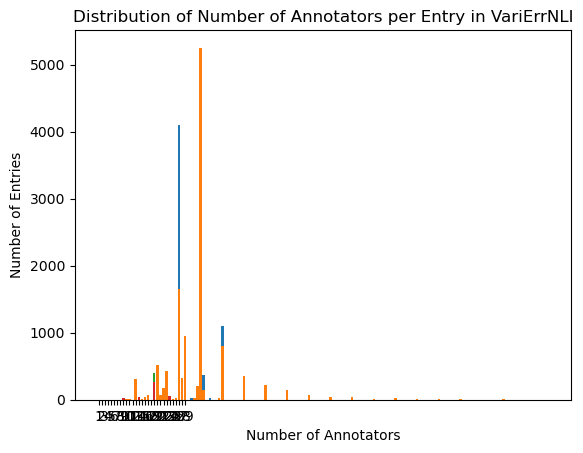

In [48]:
# generate the distribution of number of annotators for each entry in the dataset for each dataset

import json
import os
from src.load_data import load_data
import matplotlib.pyplot as plt


def count_annotators_per_entry(dataset_name):
    '''input: dataset_name
    output: distribution of number of annotators for each entry in the dataset
    '''

    if dataset_name != "VariErrNLI":
        train_data = load_data(config['data'][dataset_name]['train_file'])
    else:
        train_data = load_data(config['data'][dataset_name]['train_file'], is_varierrnli=True)

    target_soft_labels, target_pes, annotators_pes, ids, data = train_data
    print(f"{dataset_name} - Number of entries: {len(data)}")

    # calculate and use plt to display how many annotators annotated each entry
    annotators_count = [len(annotators) for annotators in annotators_pes]
    plt.hist(annotators_count, bins=range(1, max(annotators_count) + 2), align='left', rwidth=0.8)
    plt.xlabel('Number of Annotators')
    plt.ylabel('Number of Entries')
    plt.title(f'Distribution of Number of Annotators per Entry in {dataset_name}')
    plt.xticks(range(1, max(annotators_count) + 1))
    plt.grid(axis='y')


for dataset_name in config['data_names']:
    count_annotators_per_entry(dataset_name)